# Import necessary libraries
This cell imports libraries for data preprocessing (`pandas`, `numpy`), model building (`RandomForestClassifier`), data splitting (`train_test_split`), evaluation (`accuracy_score`, `classification_report`), handling class imbalance (`SMOTE`), and encoding categorical variables (`LabelEncoder`).


In [1]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Clear previous model predictions
This cell clears the contents of the `RandomForestResult.csv` file by overwriting it with an empty string, ensuring that previous model predictions do not interfere with new results.


In [2]:
# clear the model predictions csv
with open('RandomForestResult.csv', 'w') as file:
    file.write('')

# Load the filtered dataset
This cell loads the pre-filtered dataset `customer_profit_status.csv` into a pandas DataFrame for further processing and modeling.


In [10]:
# Load the filtered dataset
data = pd.read_csv('../../Feature Engineering/customer_profit_status.csv')

# Load the filtered dataset
This cell loads the pre-filtered dataset `customer_profit_status.csv` into a pandas DataFrame for further processing and modeling.


In [11]:
# Define features and target
X = data[['CustomerTier', 'PercentProfit']]
y = data['QuoteStatus']

# Encode the target variable
This cell uses `LabelEncoder` to transform the categorical target variable `QuoteStatus` into numerical form, making it suitable for machine learning models.


In [12]:
# Encode the target variable 'QuoteStatus' as it is categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Apply SMOTE to balance the dataset
This cell applies the SMOTE (Synthetic Minority Over-sampling Technique) method to balance the class distribution in the entire dataset before splitting, ensuring the minority class ('Not Converted') is adequately represented.


In [14]:
# Apply SMOTE before splitting to balance the 'Not Converted' class in the entire dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

# Split the resampled data
This cell splits the SMOTE-resampled dataset into training and testing sets, using 80% of the data for training and 20% for testing, with a fixed random seed for reproducibility.


In [15]:
# Now split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

### Initialize the RandomForest Classifier Model

In this step, we create an instance of the `RandomForestClassifier` from the `sklearn.ensemble` module. The `random_state` parameter is set to `42` to ensure reproducibility of the results by controlling the randomness of the model.


In [16]:
# Initialize the RandomForest Tree model
clf = RandomForestClassifier(random_state=42)

### Train the RandomForest Classifier

We train the `RandomForestClassifier` model using the resampled training data by calling the `.fit()` method. This method takes the feature matrix `X_train` and the target labels `y_train` as inputs, allowing the model to learn patterns and relationships within the training data.


In [17]:
# Train the model on the resampled training data
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Make Predictions on the Test Set

After training the model, we use the `.predict()` method to generate predictions on the test feature set `X_test`. The predicted class labels are stored in the `y_pred` variable for further evaluation.


In [18]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

### Get Prediction Confidence Percentages

We use the `.predict_proba()` method to obtain the class probability estimates for each instance in the test set `X_test`. This returns an array `y_prob` containing the probability for each class.  
To determine the model's confidence in its predictions, we find the maximum probability for each instance using `np.max()` along `axis=1` and multiply by 100 to convert it into a percentage. The resulting confidence values are stored in the `confidence` variable.


In [19]:
# Get confidence percentages (probabilities of predictions)
y_prob = clf.predict_proba(X_test)
confidence = np.max(y_prob, axis=1) * 100  # Convert to percentage

### Evaluate the Model Performance

We evaluate the performance of the trained model by calculating its accuracy using the `accuracy_score()` function from `sklearn.metrics`. This function compares the predicted labels `y_pred` with the true labels `y_test` and returns the proportion of correct predictions. The accuracy is then printed with two decimal places for readability.


In [21]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.77


# Generating a Detailed Classification Report

This code prints a detailed classification report for the model's predictions. It compares the true labels (`y_test`) with the predicted labels (`y_pred`) and shows key performance metrics like precision, recall, f1-score, and support for each class. The `target_names` parameter uses the class names obtained from `label_encoder.classes_` to make the report more readable.


In [22]:
# Detailed classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

        Lost       0.78      0.76      0.77     17481
         Won       0.77      0.79      0.78     17334

    accuracy                           0.77     34815
   macro avg       0.77      0.77      0.77     34815
weighted avg       0.77      0.77      0.77     34815



# Preparing Output Data for CSV Export

This code prepares the test set results for export. It starts by copying the features from `X_test`, then adds three new columns:  
- `Actual Status`: the true labels, decoded back to their original class names using the label encoder.  
- `Predicted Status`: the predicted labels, also decoded.  
- `Confidence (%)`: the model's prediction confidence for each sample, expressed as a percentage.


In [23]:
# Prepare the output data for CSV
output_data = X_test.copy()
output_data['Actual Status'] = label_encoder.inverse_transform(y_test)
output_data['Predicted Status'] = label_encoder.inverse_transform(y_pred)
output_data['Confidence (%)'] = confidence

# Saving the Results to a CSV File

This code saves the prepared output data (`output_data`) to a CSV file named `RandomForestResult.csv`.  
The `index=False` argument ensures that the DataFrame index is not included in the CSV.  
After saving, it prints a confirmation message indicating the file was successfully created.


In [26]:
# Save to CSV
output_data.to_csv('RandomForestResult.csv', index=False)
print("Predictions have been saved to 'RandomForestResult.csv'")

Predictions have been saved to 'RandomForestResult.csv'


## Visual analysis of the RandomForest results

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
data = pd.read_csv('RandomForestResult.csv')

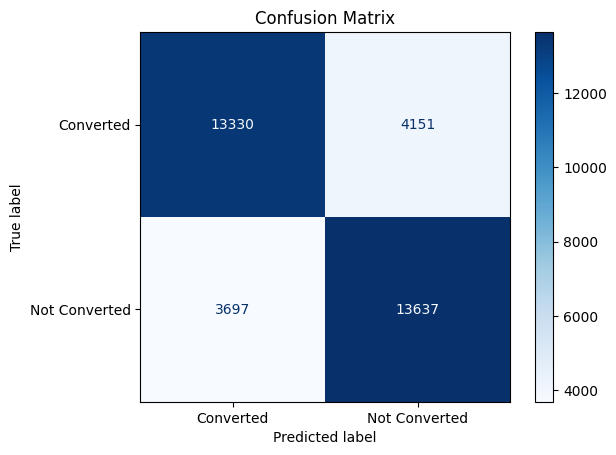

In [29]:
# Confusion Matrix
cm = confusion_matrix(data['Actual Status'], data['Predicted Status'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Converted', 'Not Converted'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


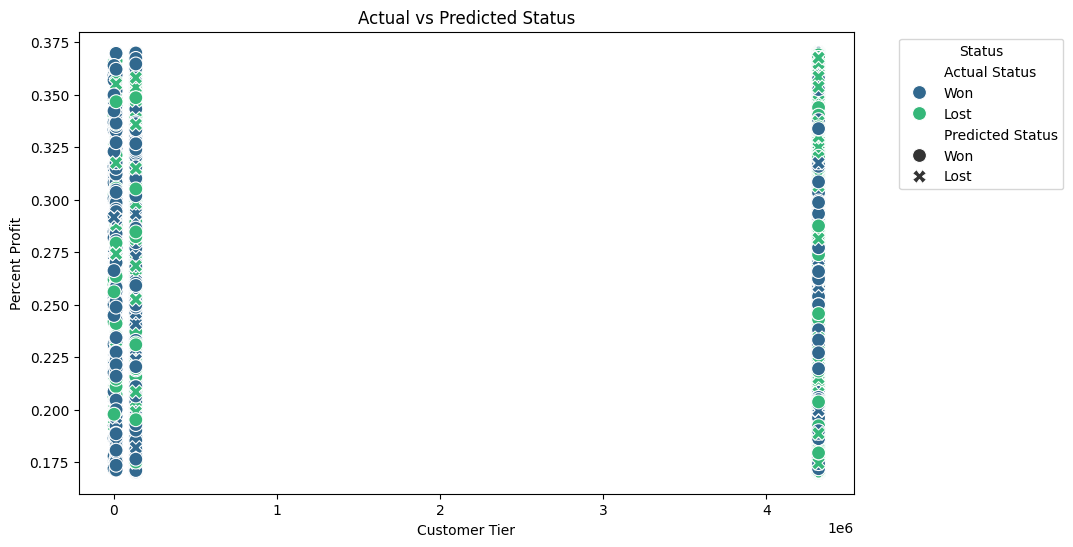

In [30]:
# Scatter Plot of Features (CustomerTier vs PercentProfit)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='CustomerTier', y='PercentProfit', hue='Actual Status', style='Predicted Status',
    data=data, palette='viridis', markers=['o', 'X'], s=100
)
plt.title('Actual vs Predicted Status')
plt.xlabel('Customer Tier')
plt.ylabel('Percent Profit')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

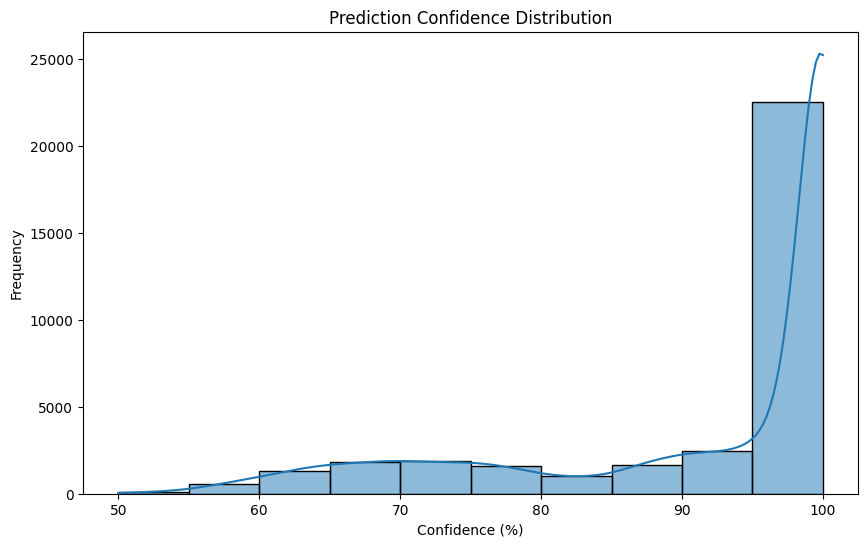

In [31]:
# Histogram of Confidence Percentages
plt.figure(figsize=(10, 6))
sns.histplot(data['Confidence (%)'], bins=10, kde=True)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence (%)')
plt.ylabel('Frequency')
plt.show()